KAPREKAR POLAR PHASE PORTRAIT: ATTRACTOR BASINS & CYCLIC ORBITS

Generating Polar Phase Portrait...

✓ Saved: kaprekar_polar_phase.png


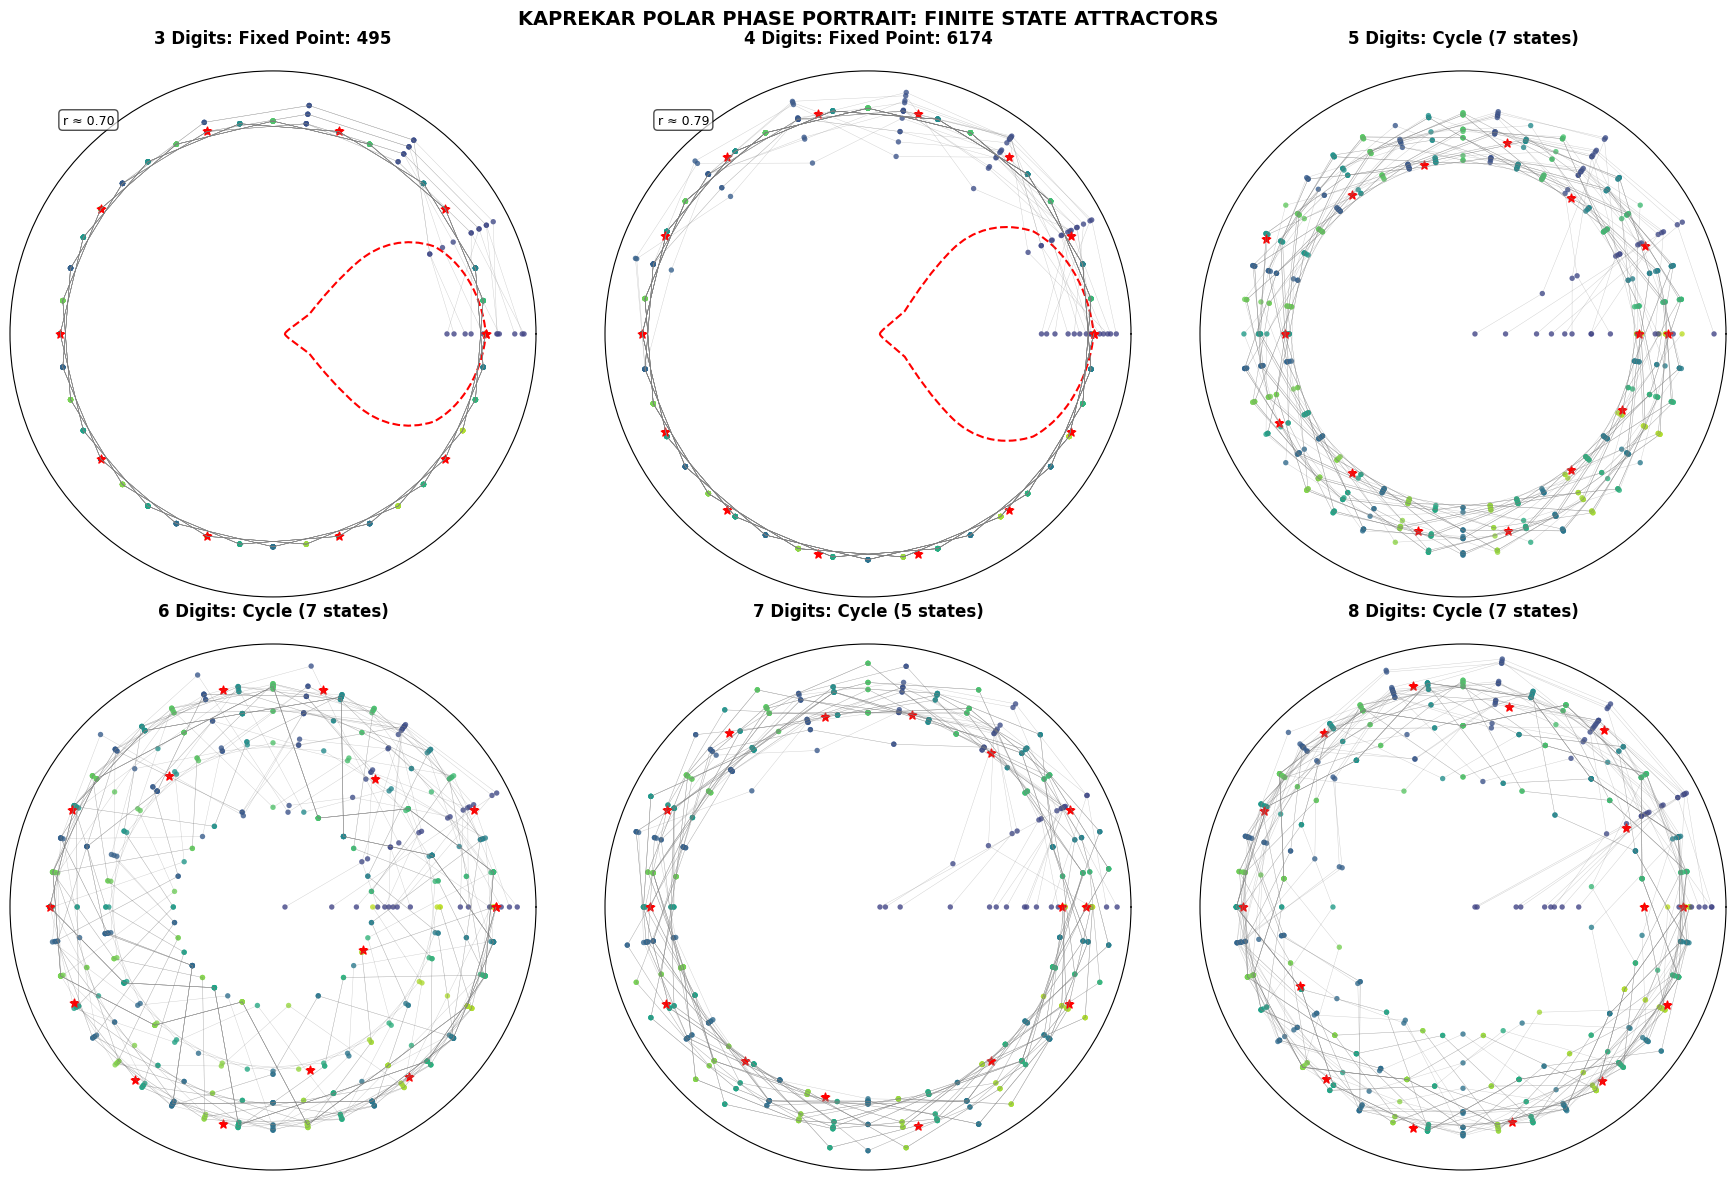


INTERPRETATION
• 3 & 4 Digits: Trajectories spiral IN to a single radius (fixed point).
• 5+ Digits: Trajectories lock into rings (limit cycles).
• No trajectory escapes. Finite alphabet → bounded phase space.
• Infinity is topologically impossible.


In [1]:
"""
kaprekar_polar_phase.py
========================
Polar Ulam-style Phase Portrait of Kaprekar Dynamics.
Reveals why 3/4 digits halt at fixed points and 5+ digits enter cycles.

Author: Néstor E. Ramos
For: "The Pixelated Universe" - Finite State Topology
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("=" * 70)
print("KAPREKAR POLAR PHASE PORTRAIT: ATTRACTOR BASINS & CYCLIC ORBITS")
print("=" * 70)

# =============================================================================
# KAPREKAR ENGINE
# =============================================================================

def kaprekar_step(n, d):
    s = f"{n:0{d}d}"
    if len(set(s)) <= 1:
        return 0
    desc = int(''.join(sorted(s, reverse=True)))
    asc = int(''.join(sorted(s)))
    return desc - asc

def generate_trajectory(start, d, max_iter=40):
    traj = [start]
    for _ in range(max_iter):
        traj.append(kaprekar_step(traj[-1], d))
    return np.array(traj)

# =============================================================================
# POLAR PHASE PORTRAIT
# =============================================================================

def plot_polar_phase():
    fig, axes = plt.subplots(2, 3, subplot_kw={'projection': 'polar'}, figsize=(18, 12))
    axes = axes.flatten()
    digits = [3, 4, 5, 6, 7, 8]

    # Colors for attractor proximity
    cmap = cm.viridis

    for idx, d in enumerate(digits):
        ax = axes[idx]

        # Run multiple trajectories to show basins
        trajectories = []
        for _ in range(15):
            start = np.random.randint(10**(d-1), 10**d)
            if len(set(f"{start:0{d}d}")) > 2:
                trajectories.append(generate_trajectory(start, d))

        # Plot trajectories
        for traj in trajectories:
            # Normalize radius: sqrt(value) / sqrt(10^d)
            r = np.sqrt(traj) / (10**(d/2))
            theta = np.linspace(0, 6*np.pi, len(traj))

            # Color by iteration (shows flow direction)
            colors = cmap(np.linspace(0.2, 0.9, len(traj)))
            ax.scatter(theta, r, c=colors, s=15, edgecolor='none', alpha=0.8)
            ax.plot(theta, r, color='gray', linewidth=0.3, alpha=0.4)

        # Mark attractor (last state)
        final_vals = [traj[-1] for traj in trajectories]
        r_final = np.sqrt(np.array(final_vals)) / (10**(d/2))
        theta_final = np.linspace(0, 6*np.pi, len(final_vals))
        ax.scatter(theta_final, r_final, c='red', s=40, marker='*', label='Attractor State')

        # Title & annotations
        unique_final = len(set(final_vals))
        if unique_final == 1 and final_vals[0] != 0:
            status = f"Fixed Point: {final_vals[0]}"
        elif unique_final == 1 and final_vals[0] == 0:
            status = "Trivial Zero"
        else:
            cycle_vals = set(final_vals)
            status = f"Cycle ({unique_final} states)"

        ax.set_title(f"{d} Digits: {status}", fontsize=12, fontweight='bold', pad=20)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.2)

        # Add radial guide for fixed point
        if unique_final == 1 and final_vals[0] != 0:
            r_fp = np.sqrt(final_vals[0]) / (10**(d/2))
            circle = plt.Circle((0,0), r_fp, fill=False, color='red', linewidth=1.5, linestyle='--')
            ax.add_patch(circle)
            ax.text(0.1, 0.9, f"r ≈ {r_fp:.2f}", transform=ax.transAxes, fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.suptitle("KAPREKAR POLAR PHASE PORTRAIT: FINITE STATE ATTRACTORS",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    fig.savefig("kaprekar_polar_phase.png", dpi=300, bbox_inches='tight')
    print("\n✓ Saved: kaprekar_polar_phase.png")
    plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("\nGenerating Polar Phase Portrait...")
    plot_polar_phase()

    print("\n" + "=" * 70)
    print("INTERPRETATION")
    print("=" * 70)
    print("• 3 & 4 Digits: Trajectories spiral IN to a single radius (fixed point).")
    print("• 5+ Digits: Trajectories lock into rings (limit cycles).")
    print("• No trajectory escapes. Finite alphabet → bounded phase space.")
    print("• Infinity is topologically impossible.")
    print("=" * 70)